# 05e - Hovmöller
Run `05-00-shared-data.ipynb` first to load data.

In [ ]:
%run 05-00-shared-data.ipynb
from utilities.style_profiles import apply_publication_style, save_fig, SINGLE_COL_IN, FULL_COL_IN, MAX_H_IN, MM, PROC_COLORS, proc_color, ENERGY_PROCESSES, HEAT_RELEASE_PROCESSES, HEAT_CONSUME_PROCESSES
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
apply_publication_style()
from utilities.plotting import create_new_jet3, create_fade_cmap, make_pastel
new_jet = create_fade_cmap(make_pastel(create_new_jet3(256), 0.5, 0.8), 4)

---
## View E – Hovmöller total-rate heatmap with dominant-process overlay

Combines the temporal and vertical dimensions in a single compact plot.
Colour shows **log₁₀(Σ|rate|)** (total absolute rate over all processes),
overlaid with semi-transparent contours for the **dominant process** per
time–height cell.  One panel per station (3 columns), one figure per
bin-range × kind combination.  Time is coarsened to `TIME_COARSEN`.

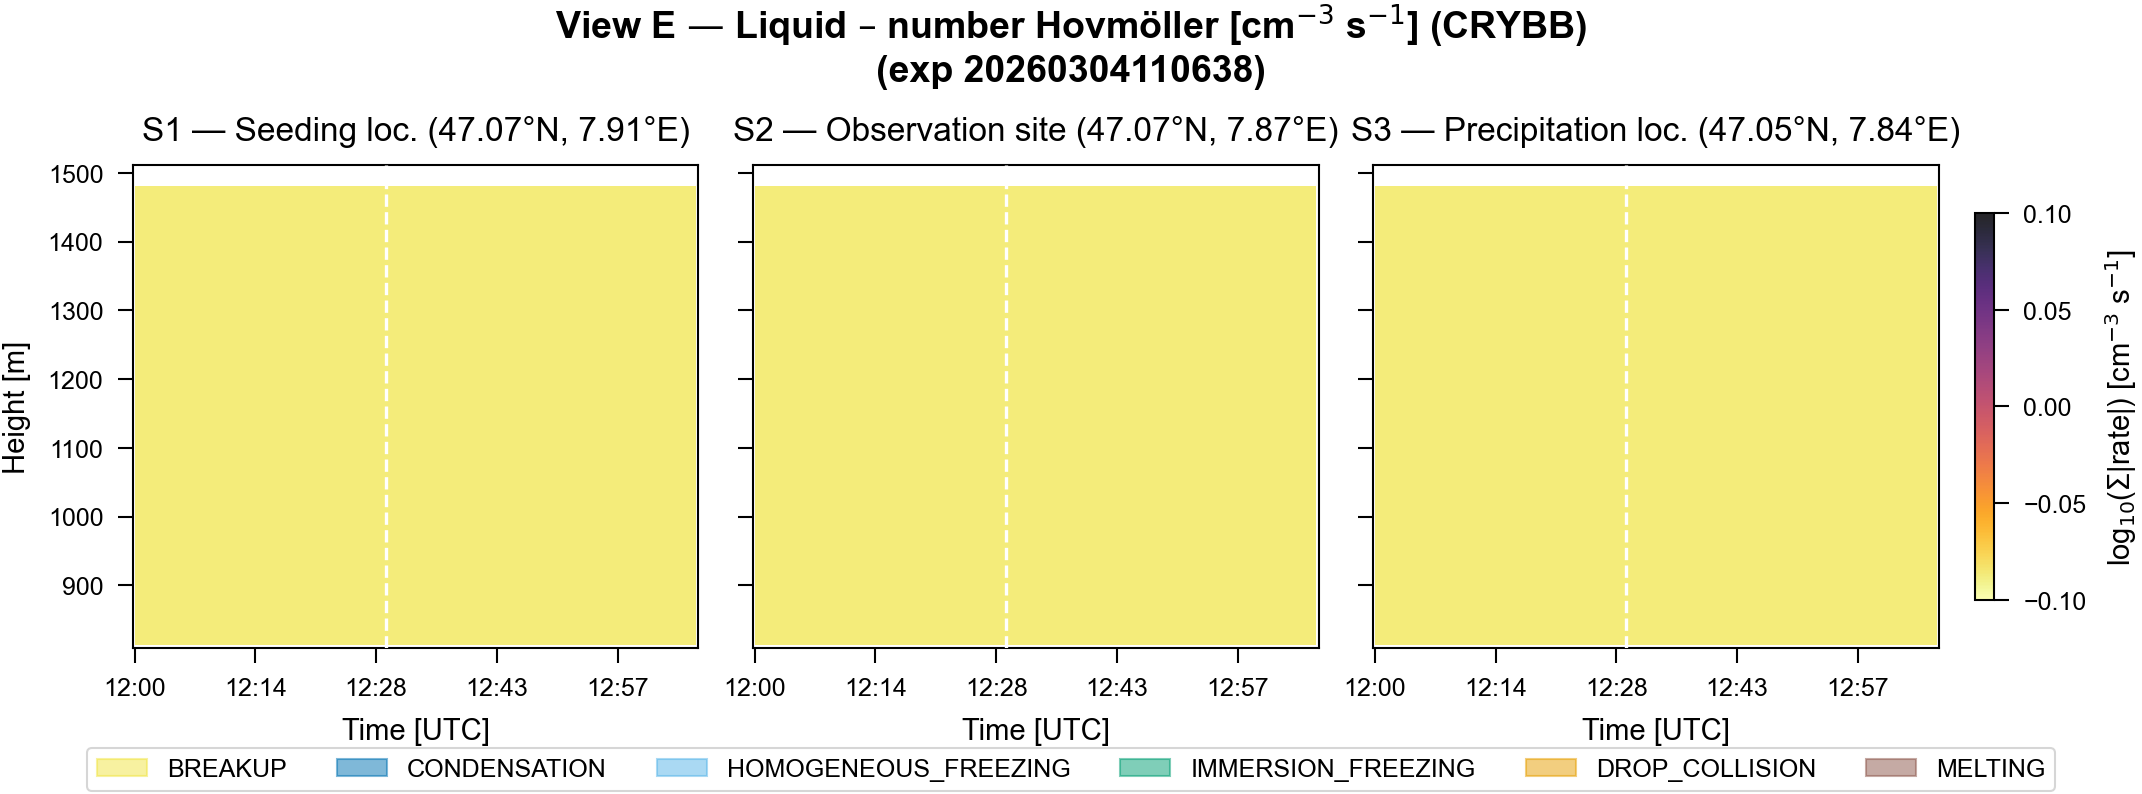

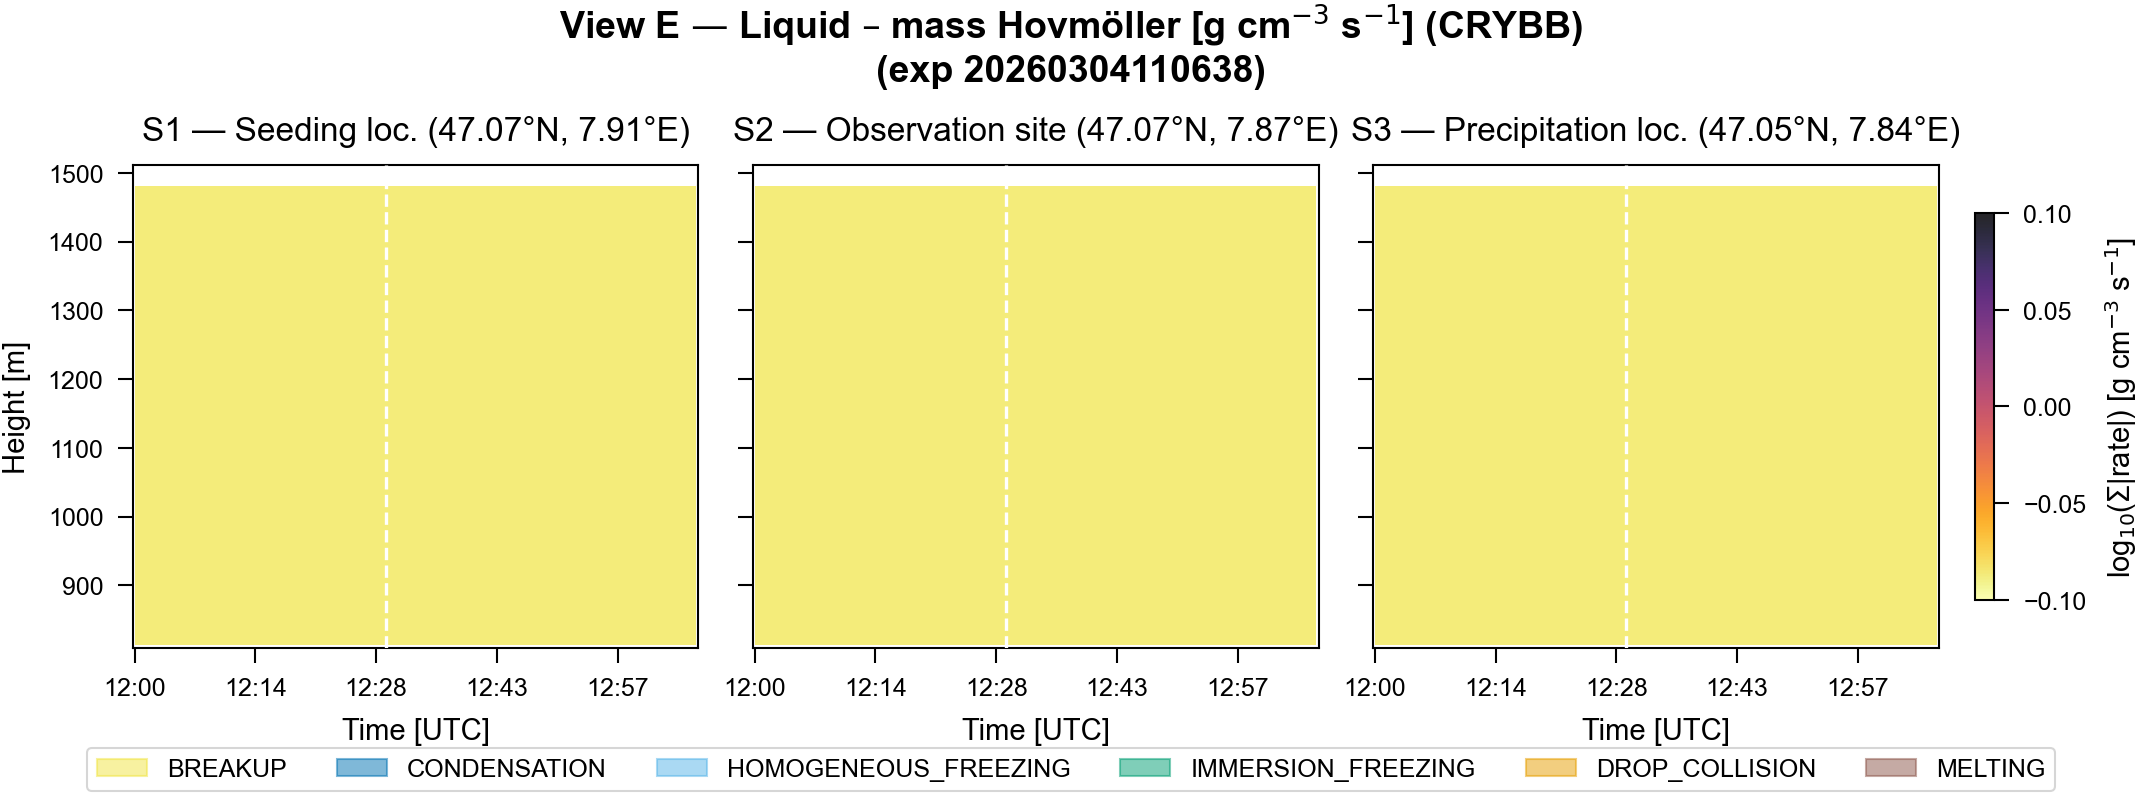

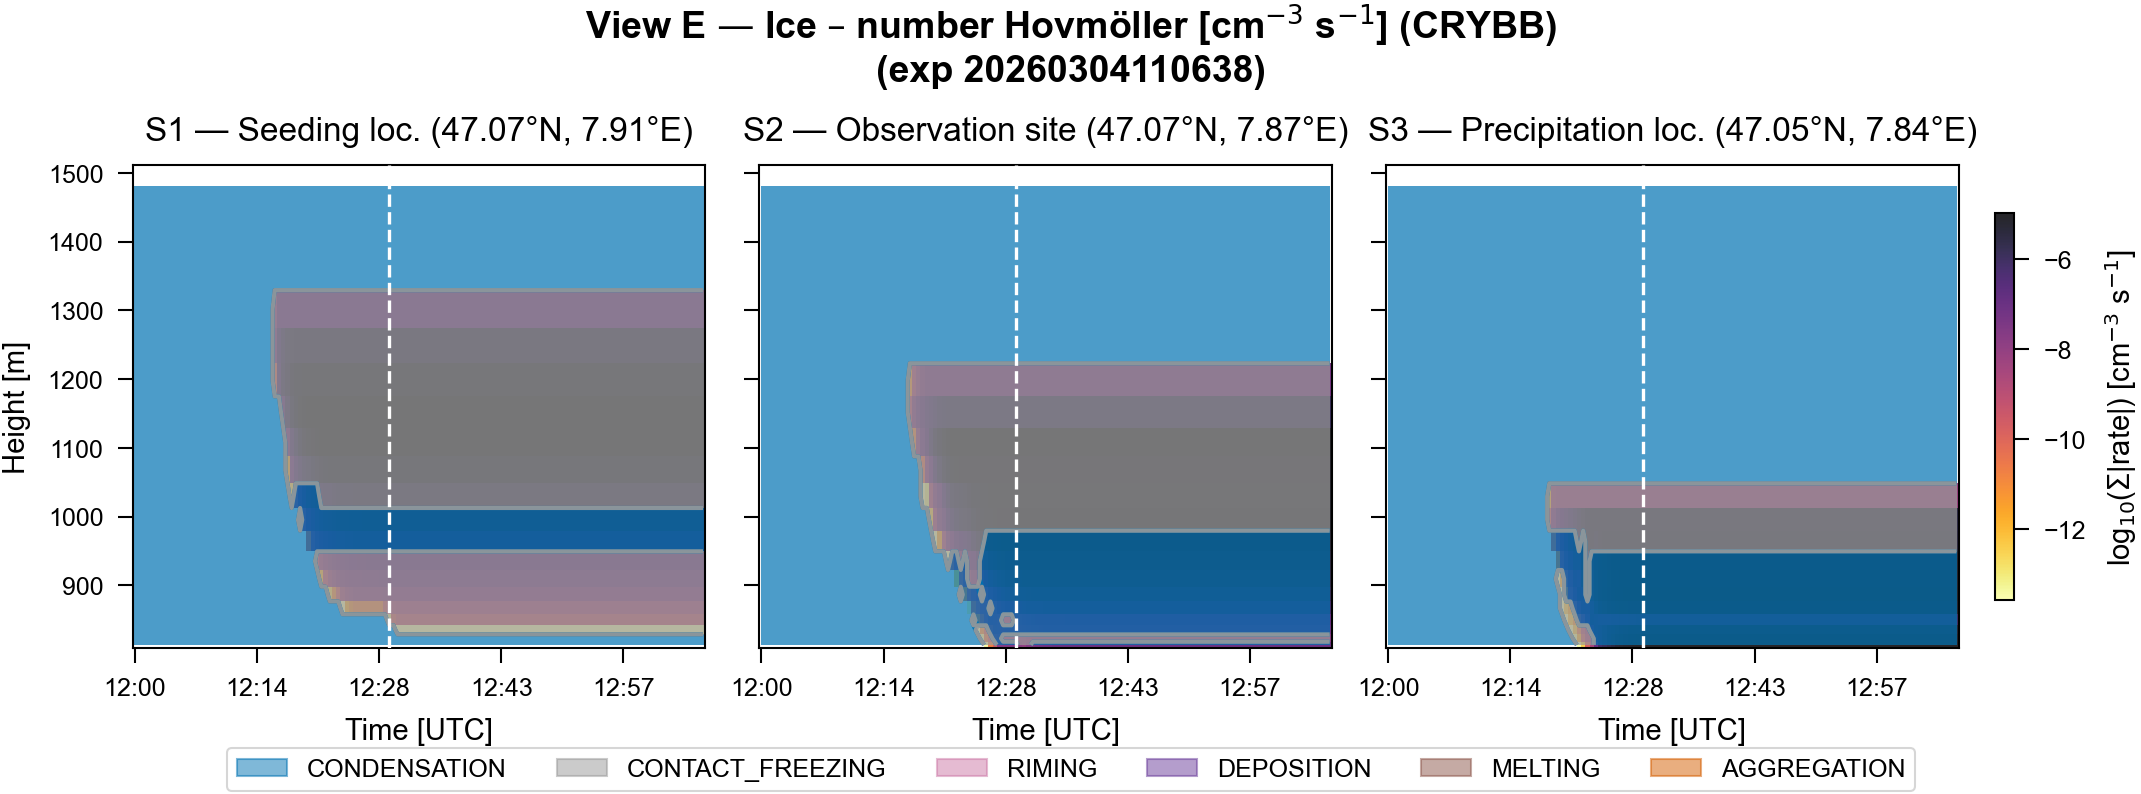

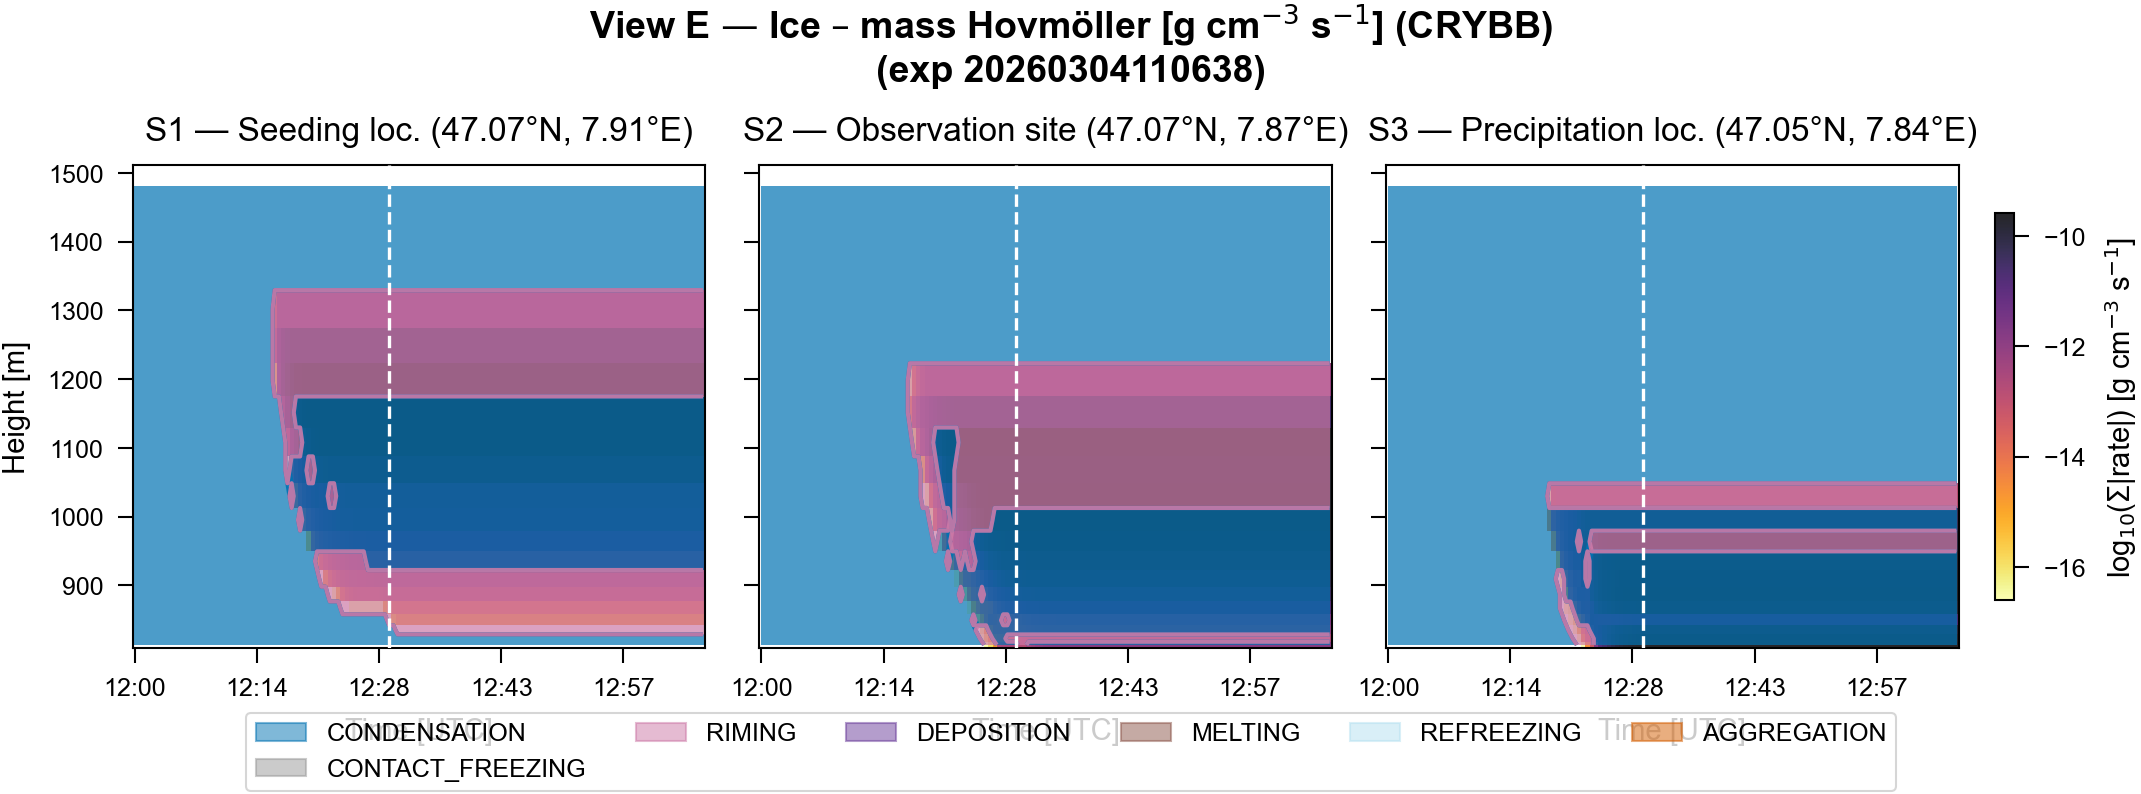

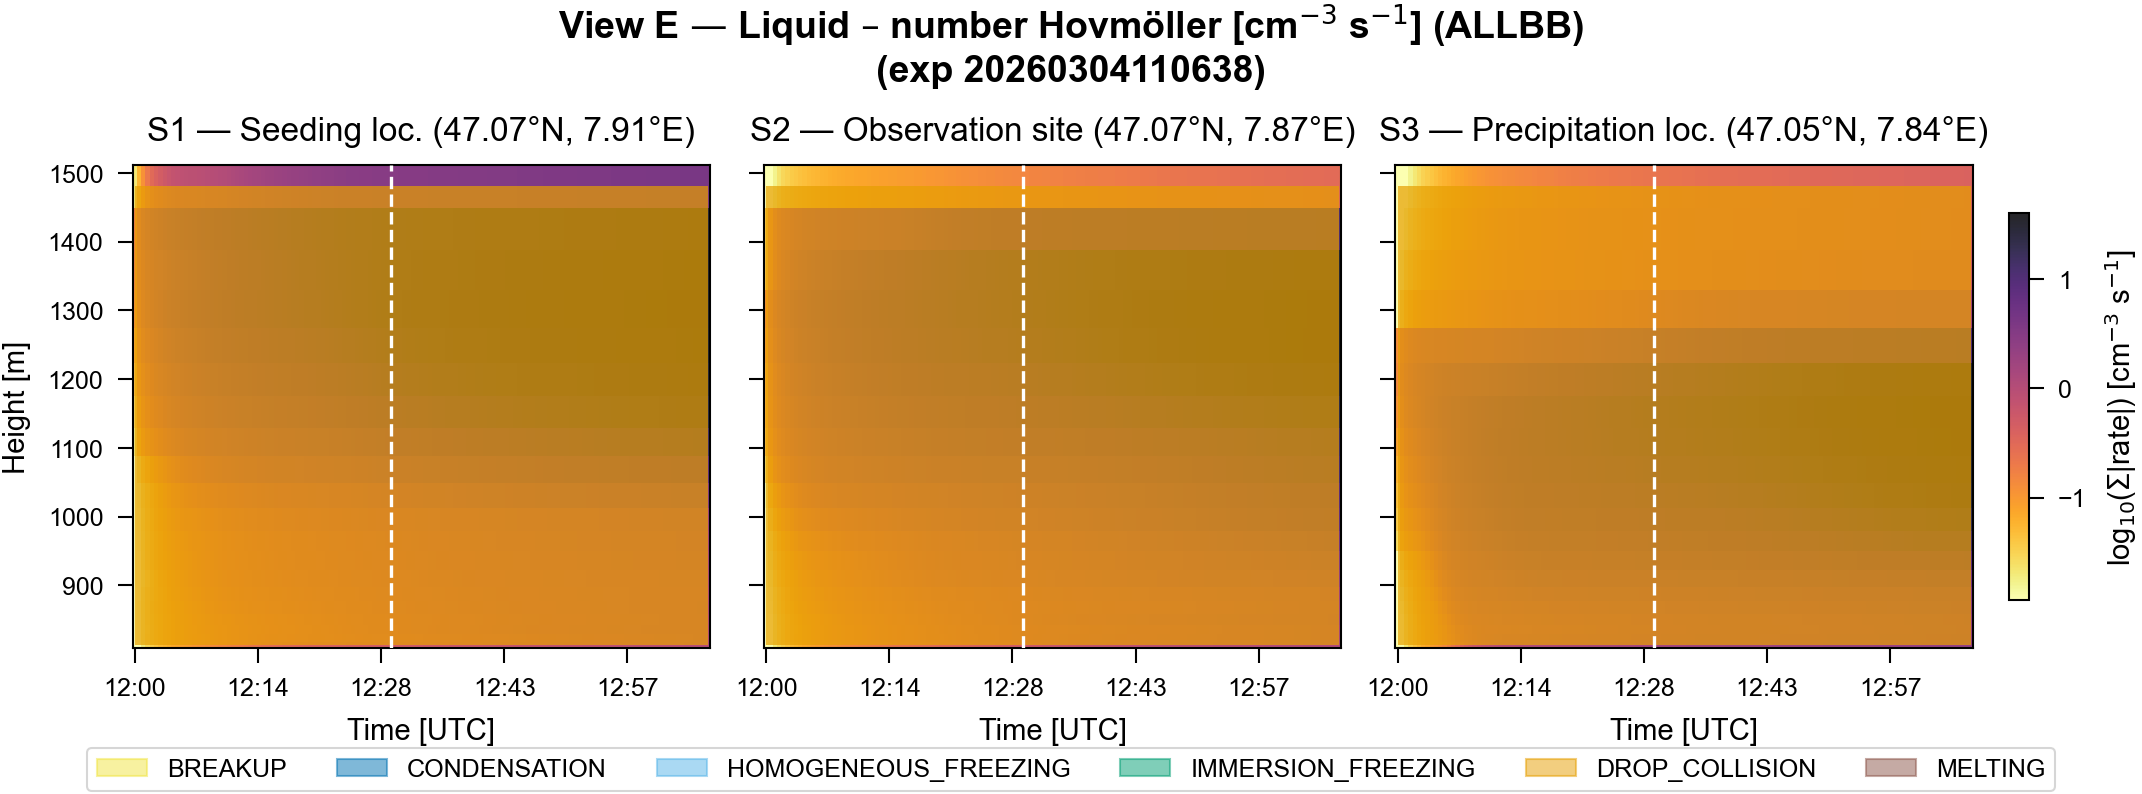

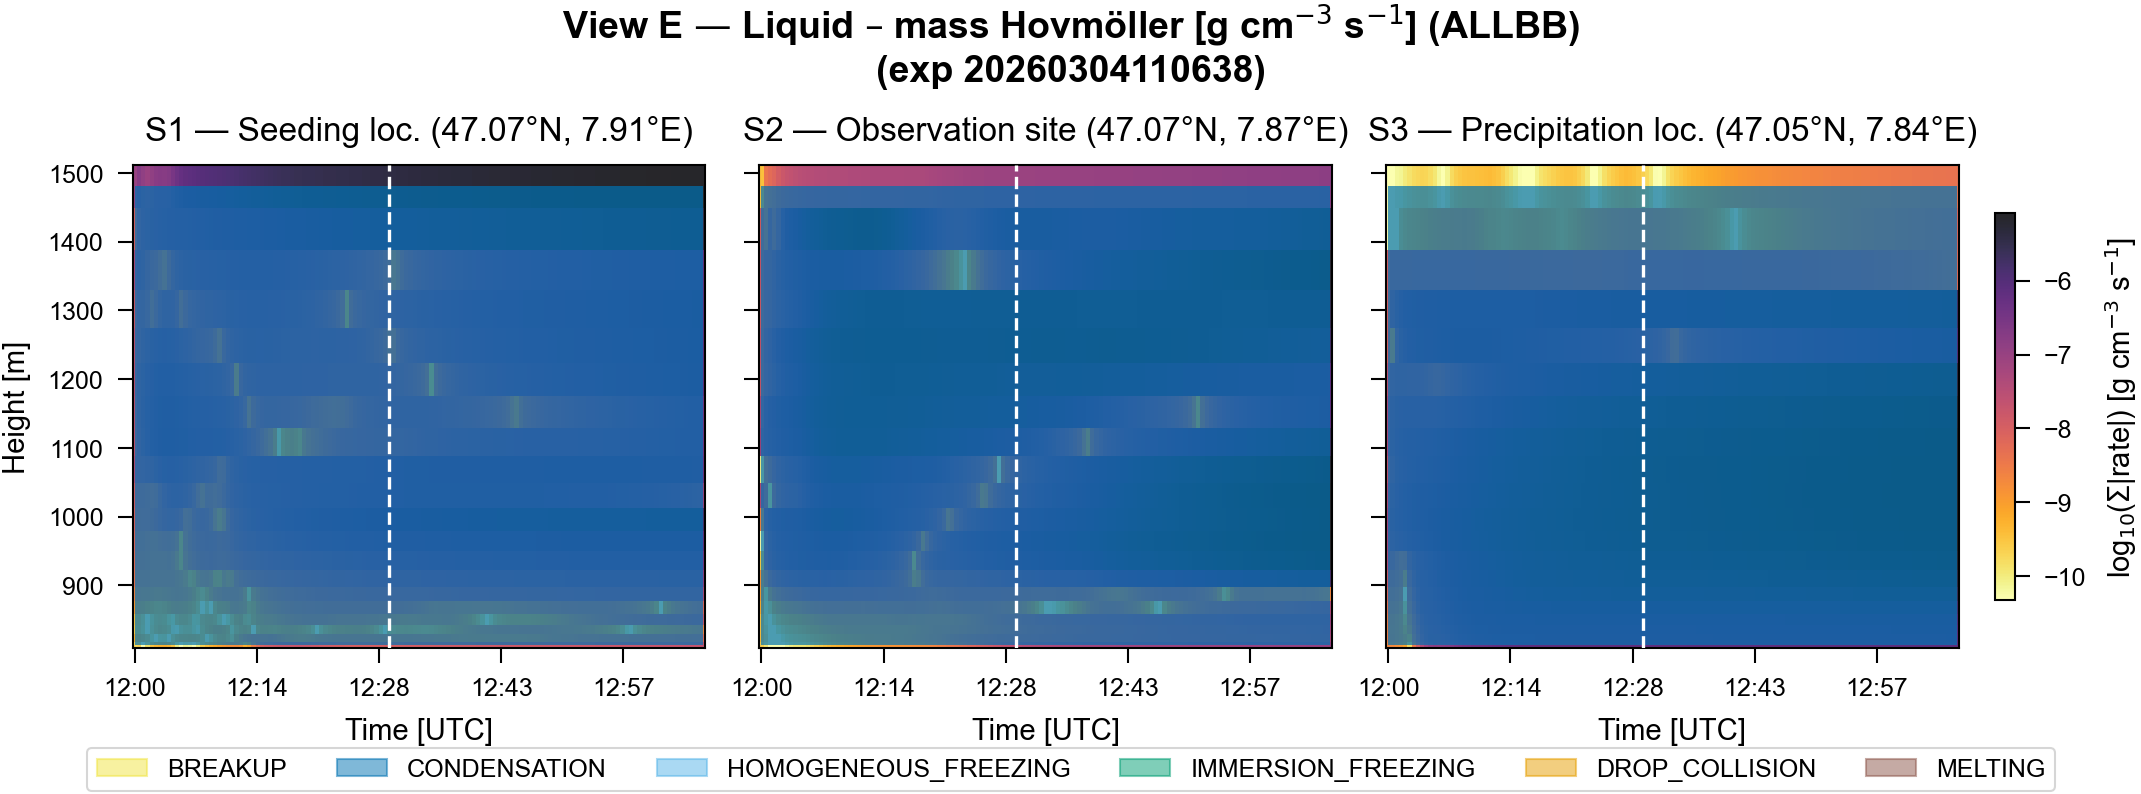

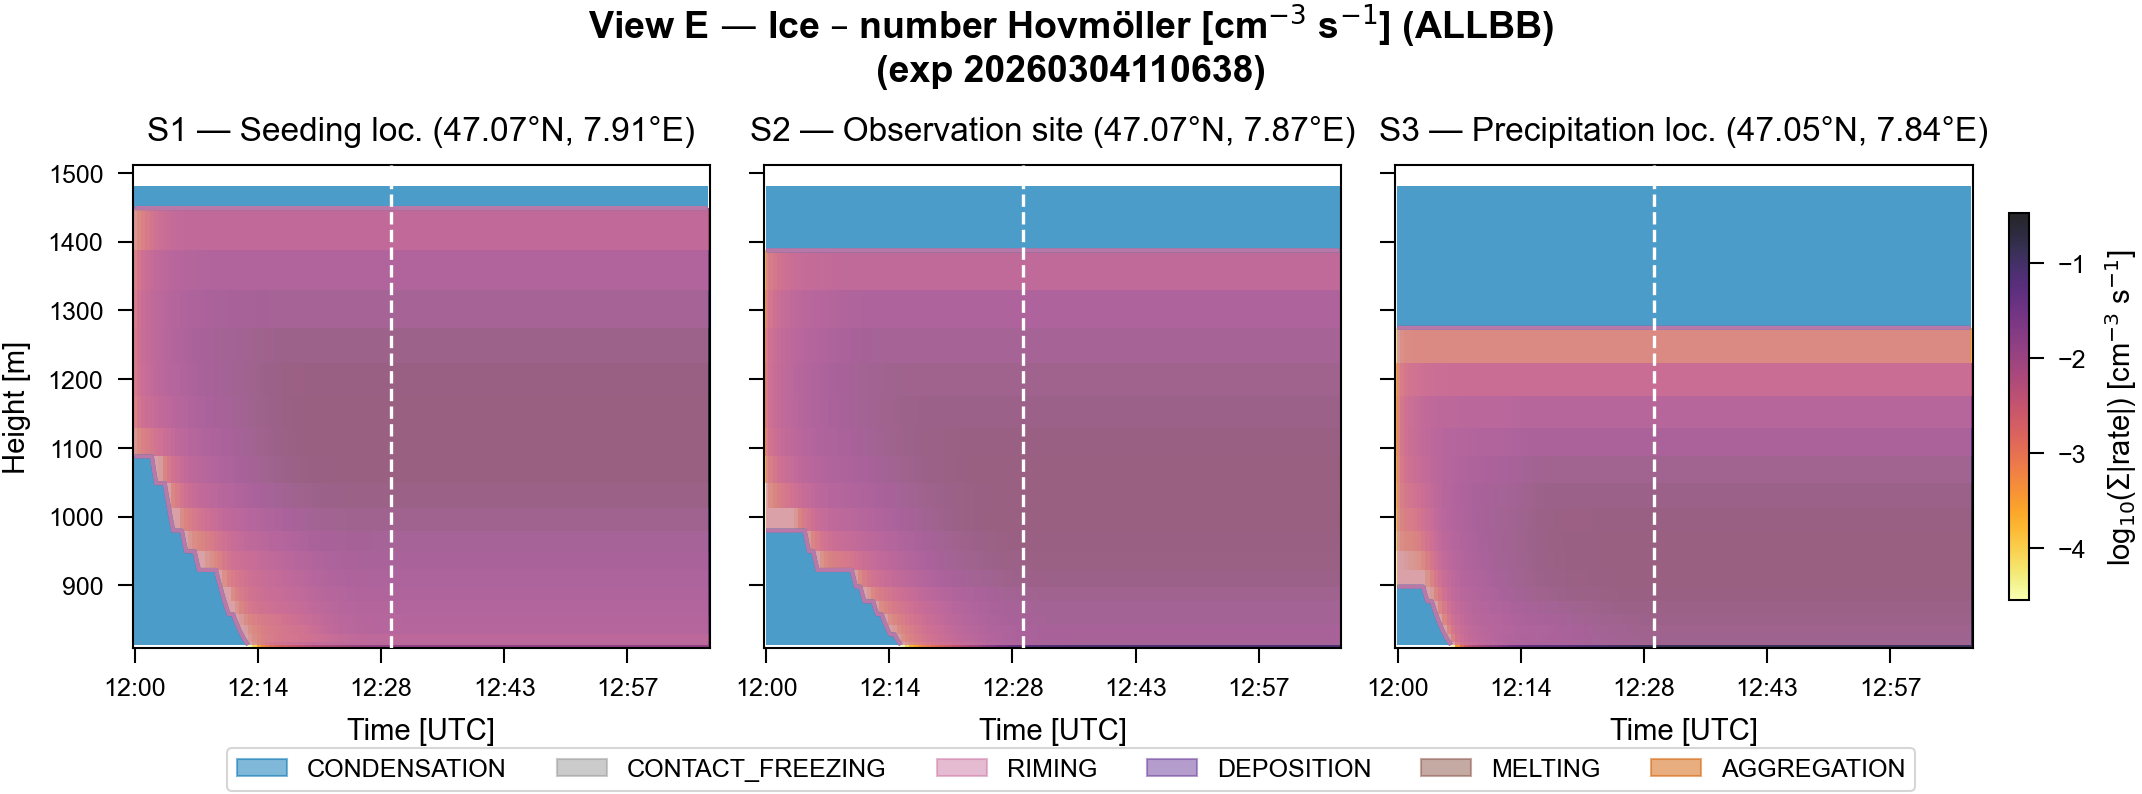

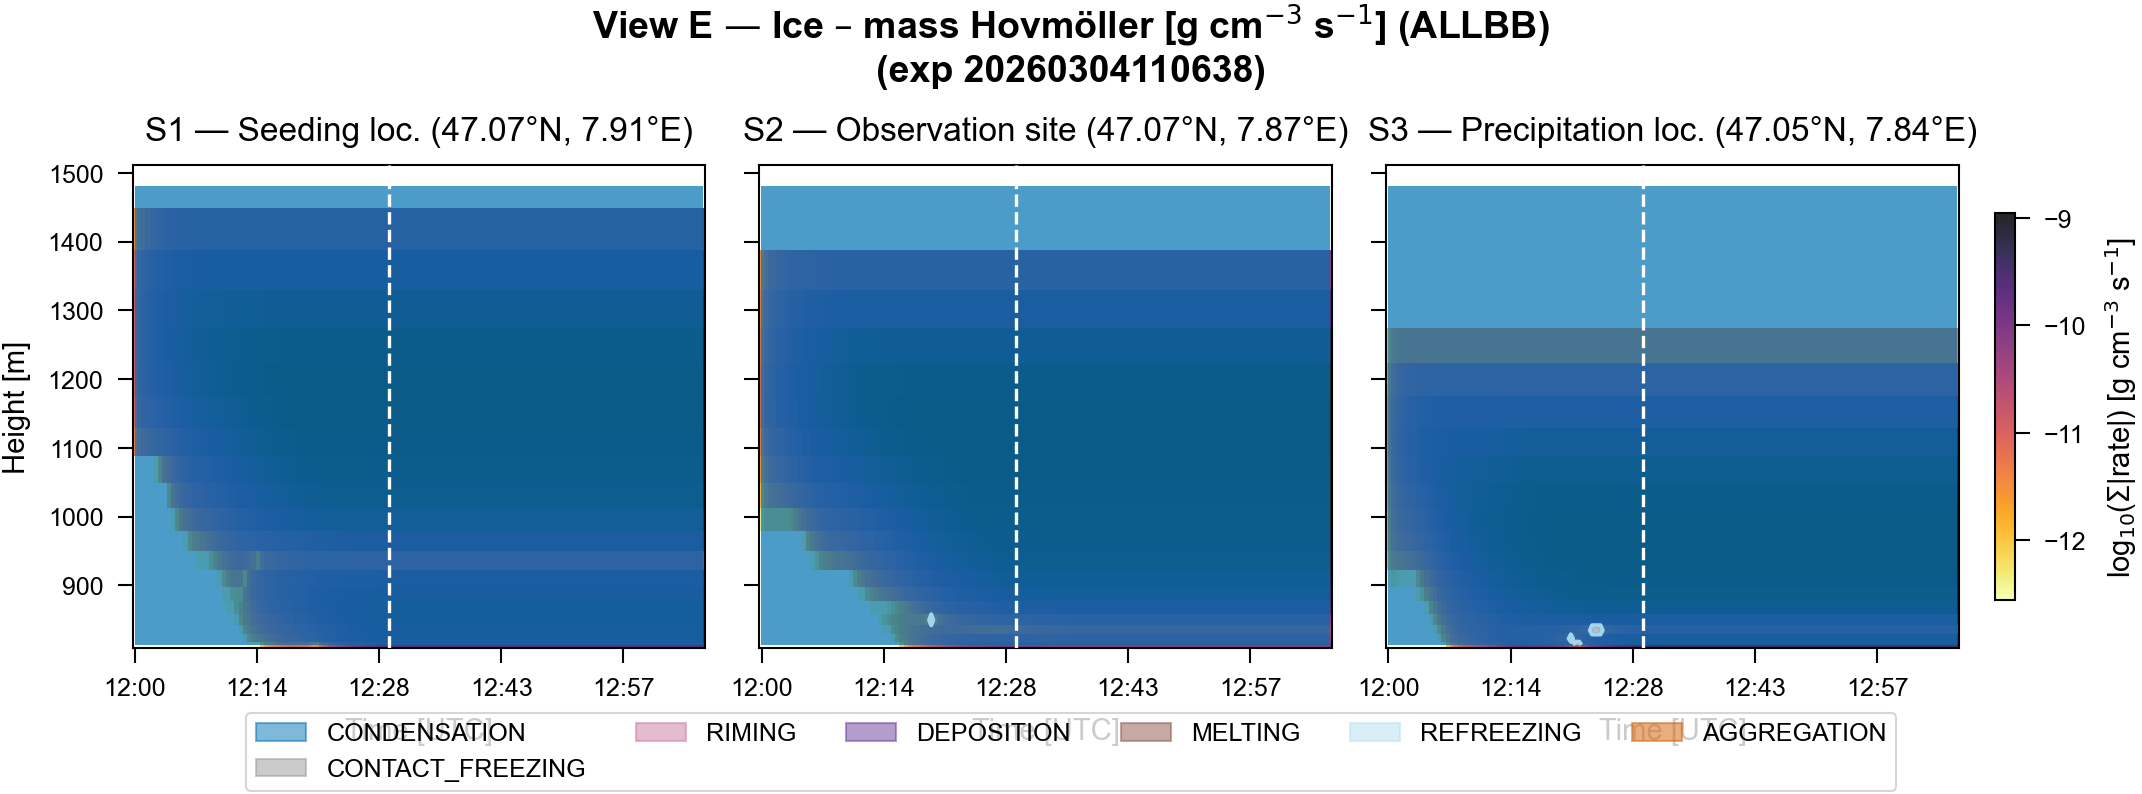

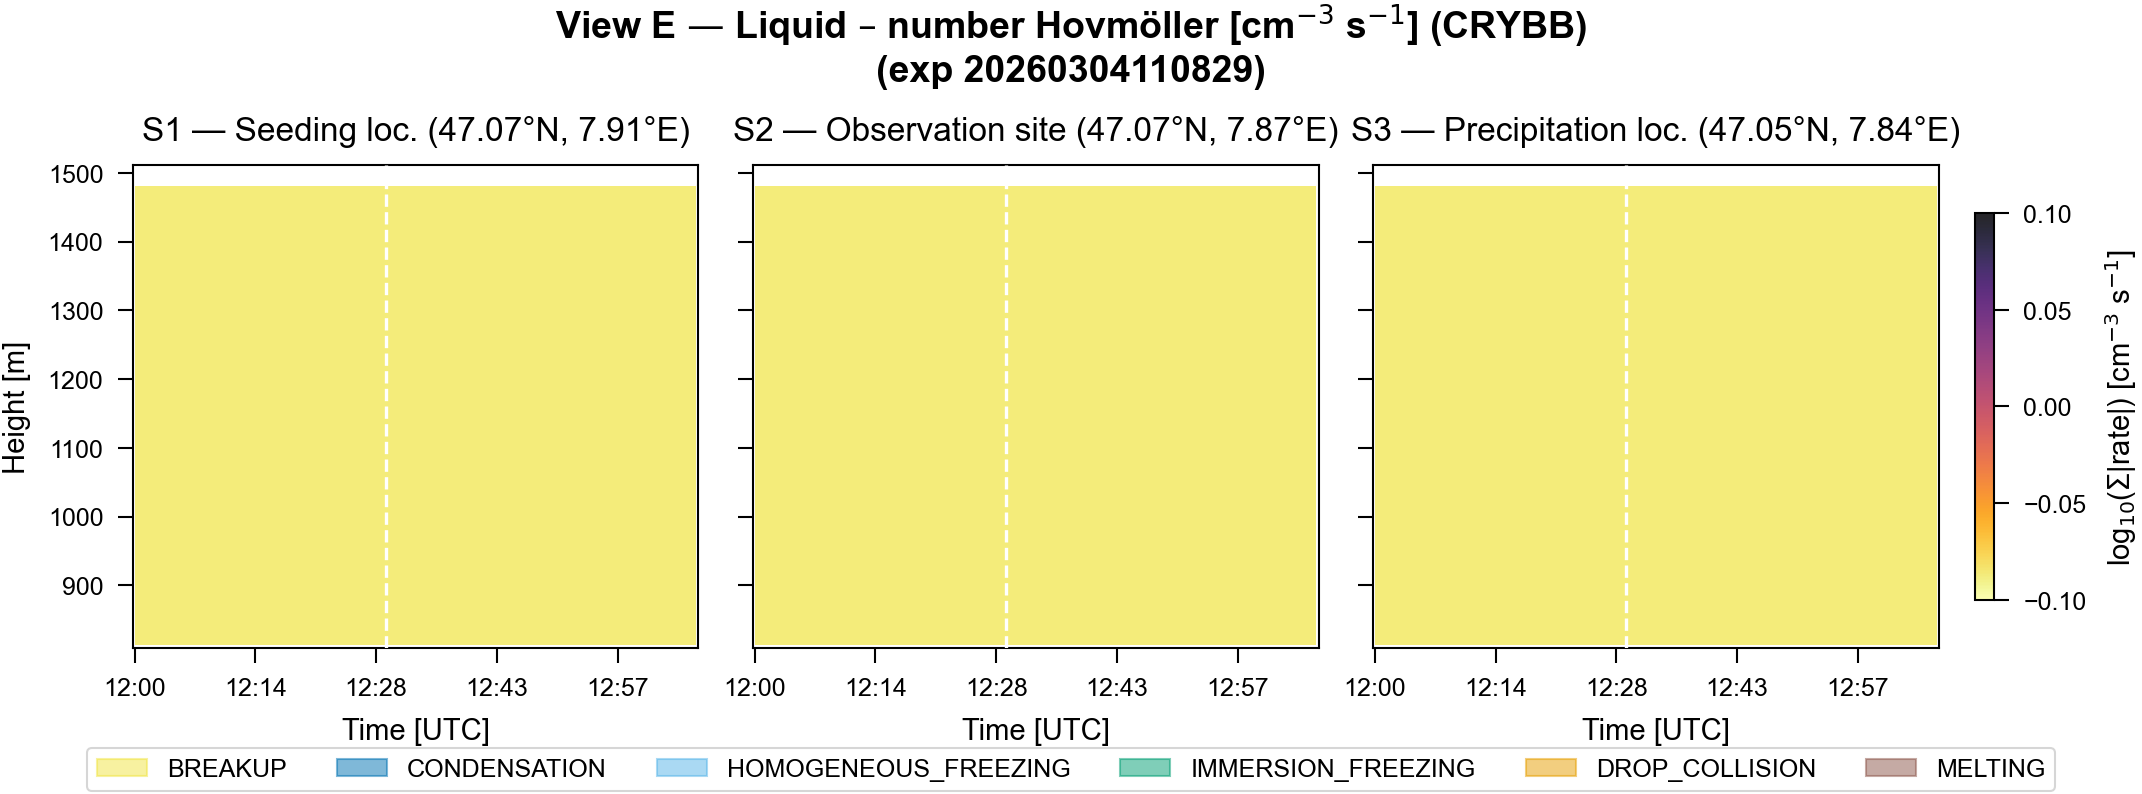

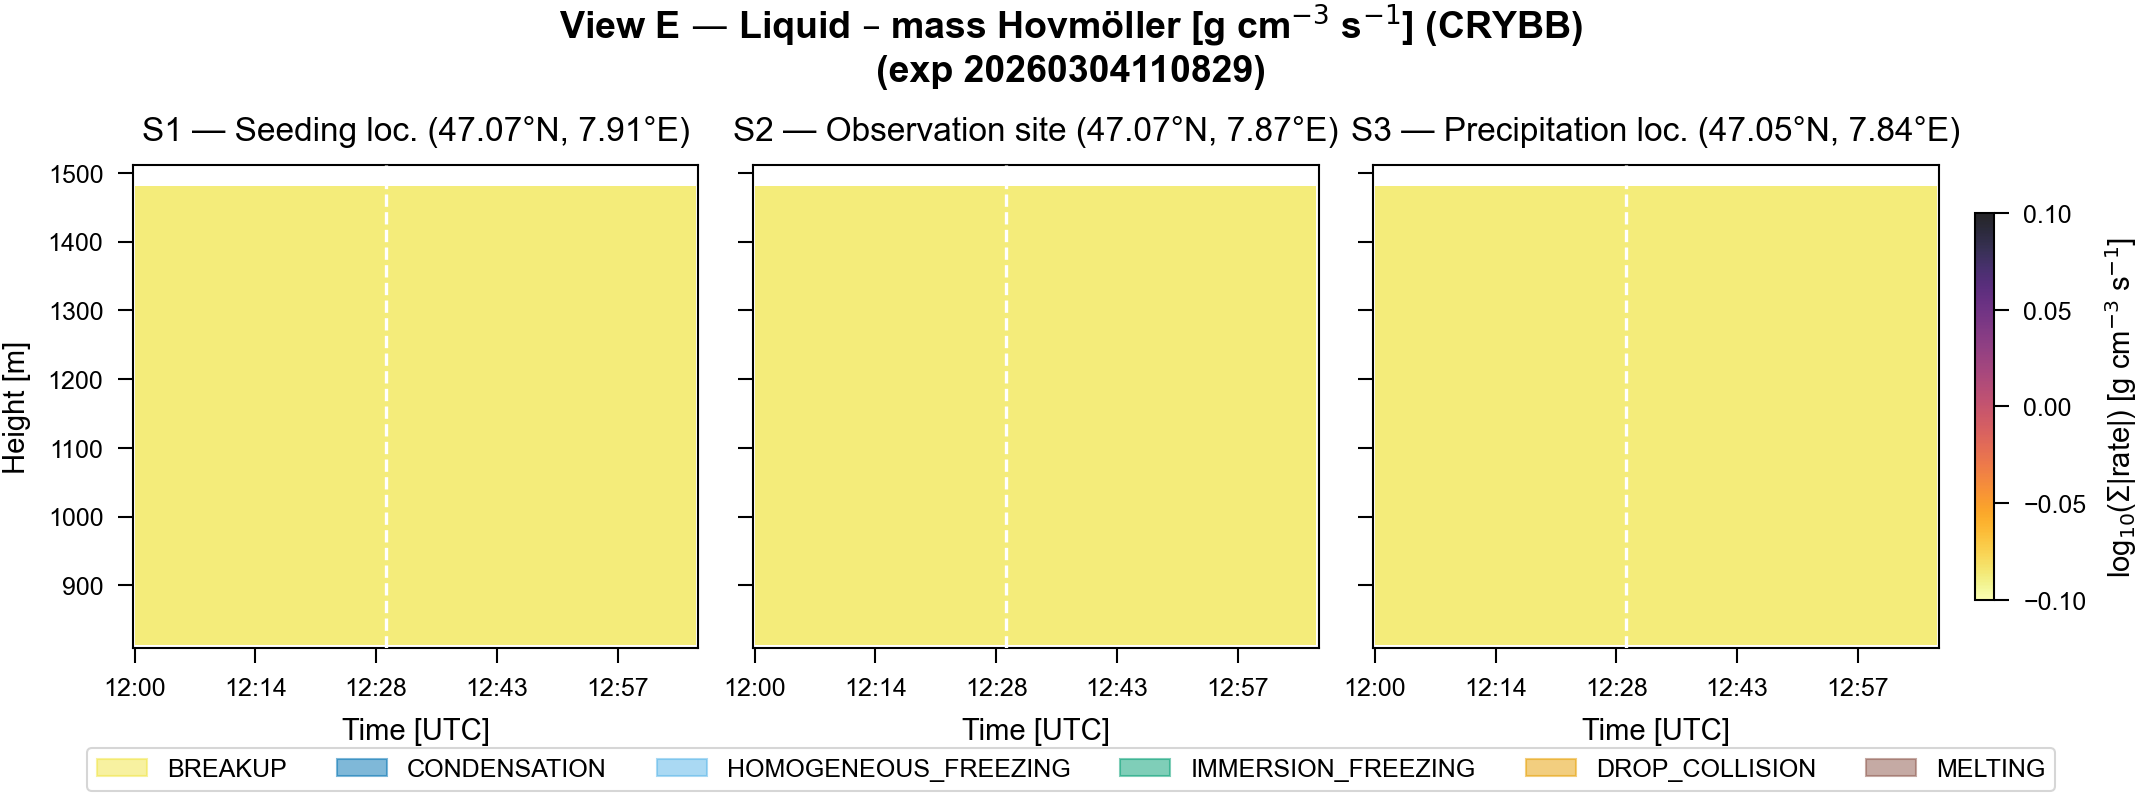

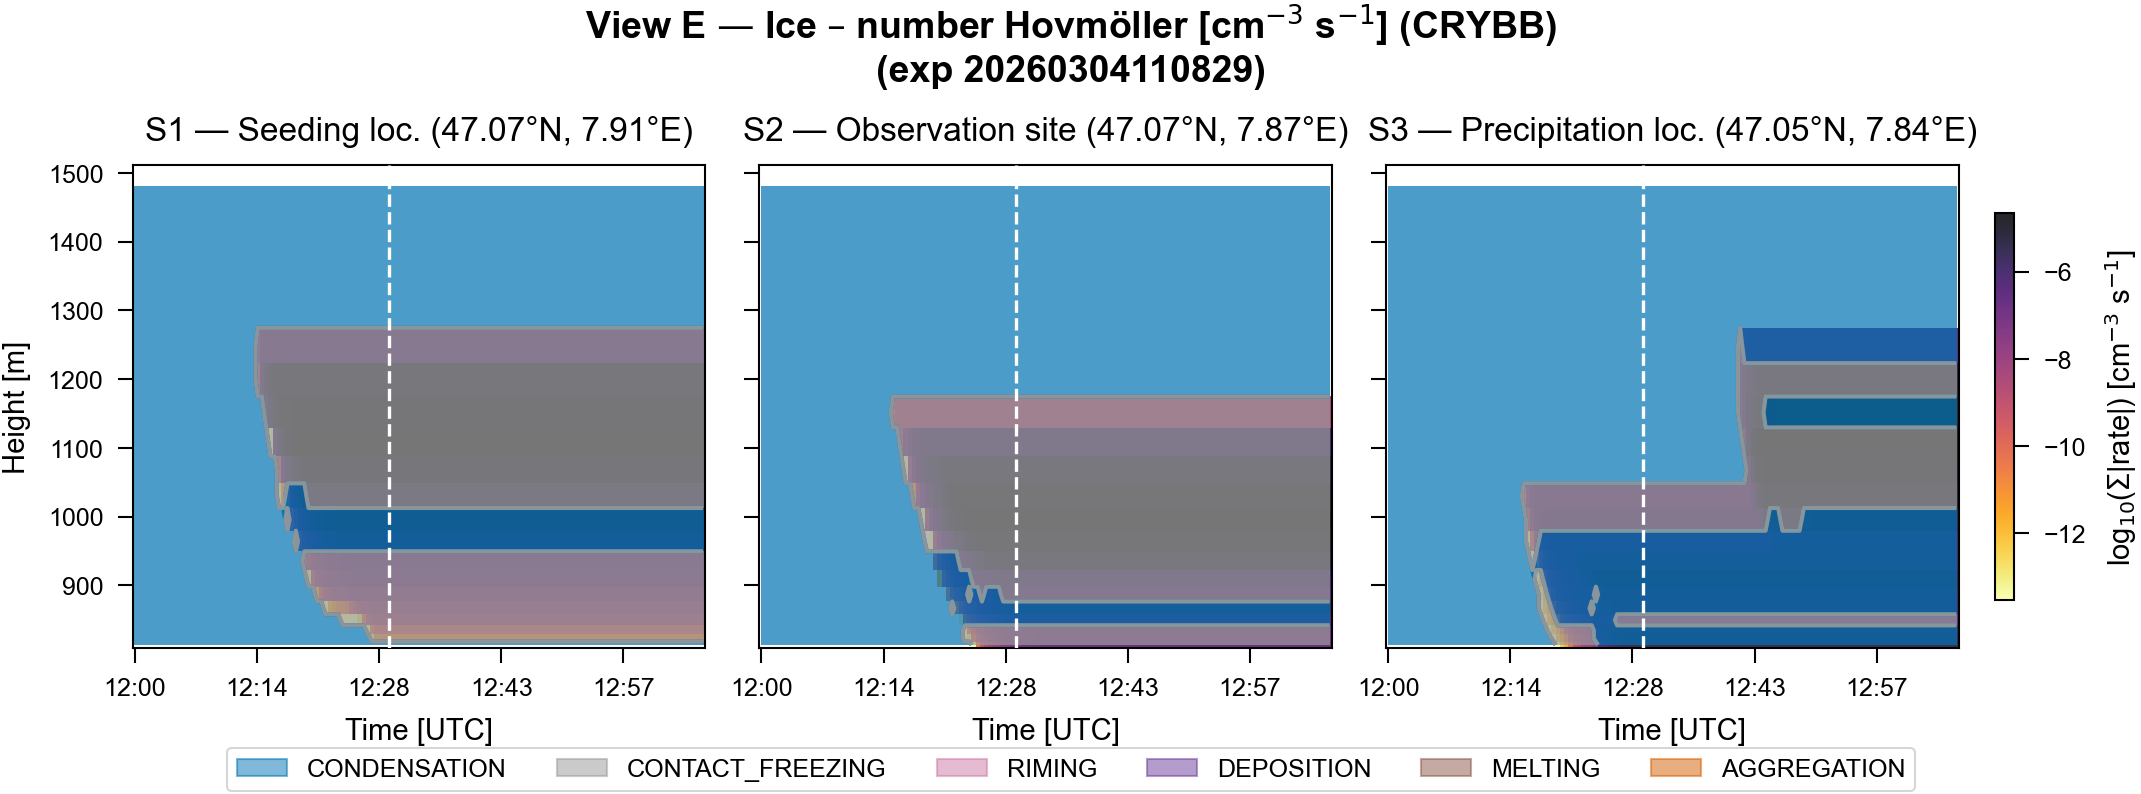

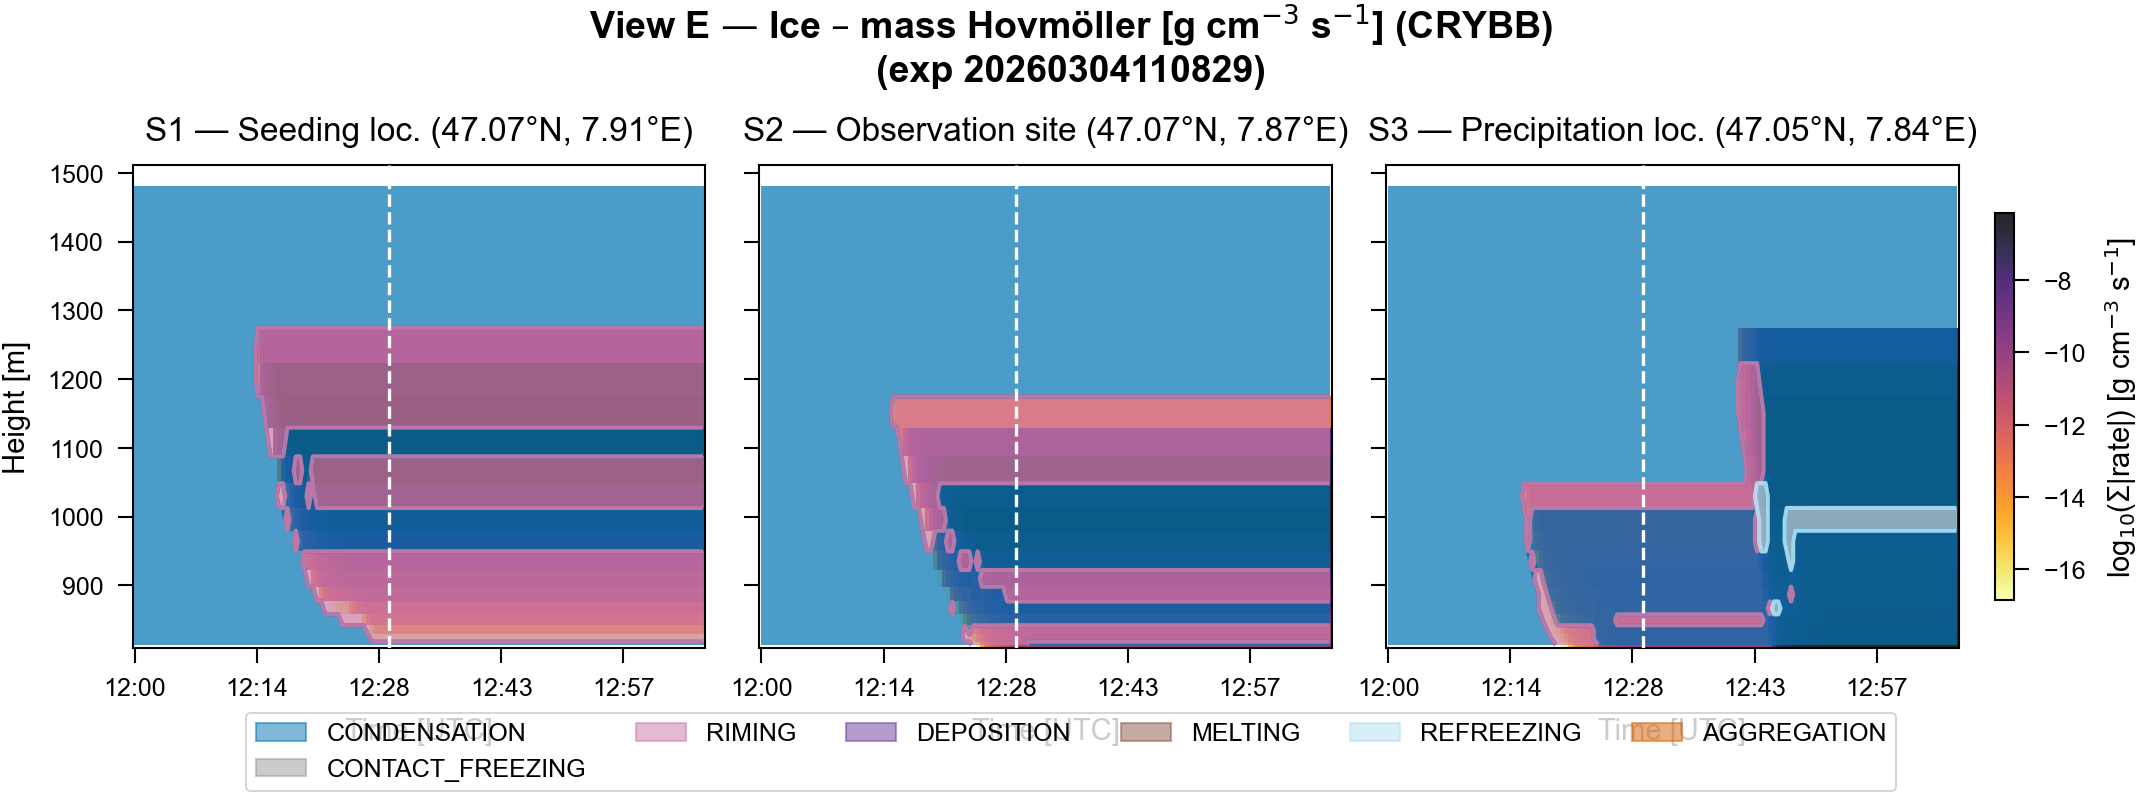

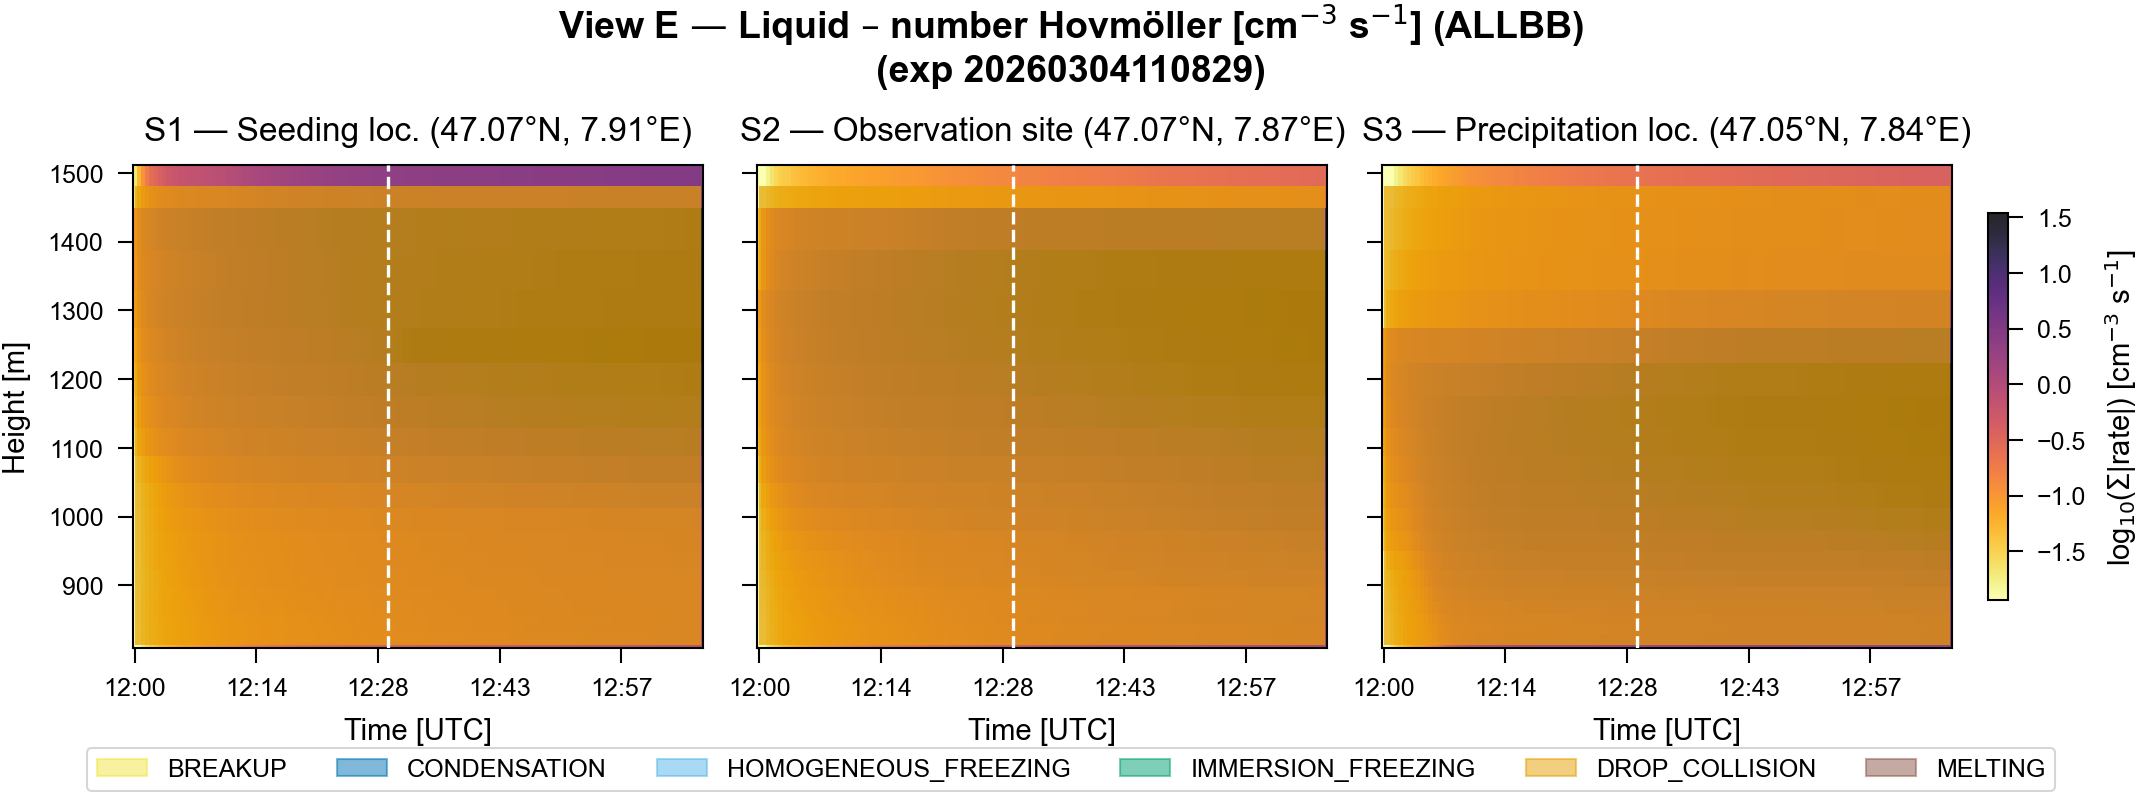

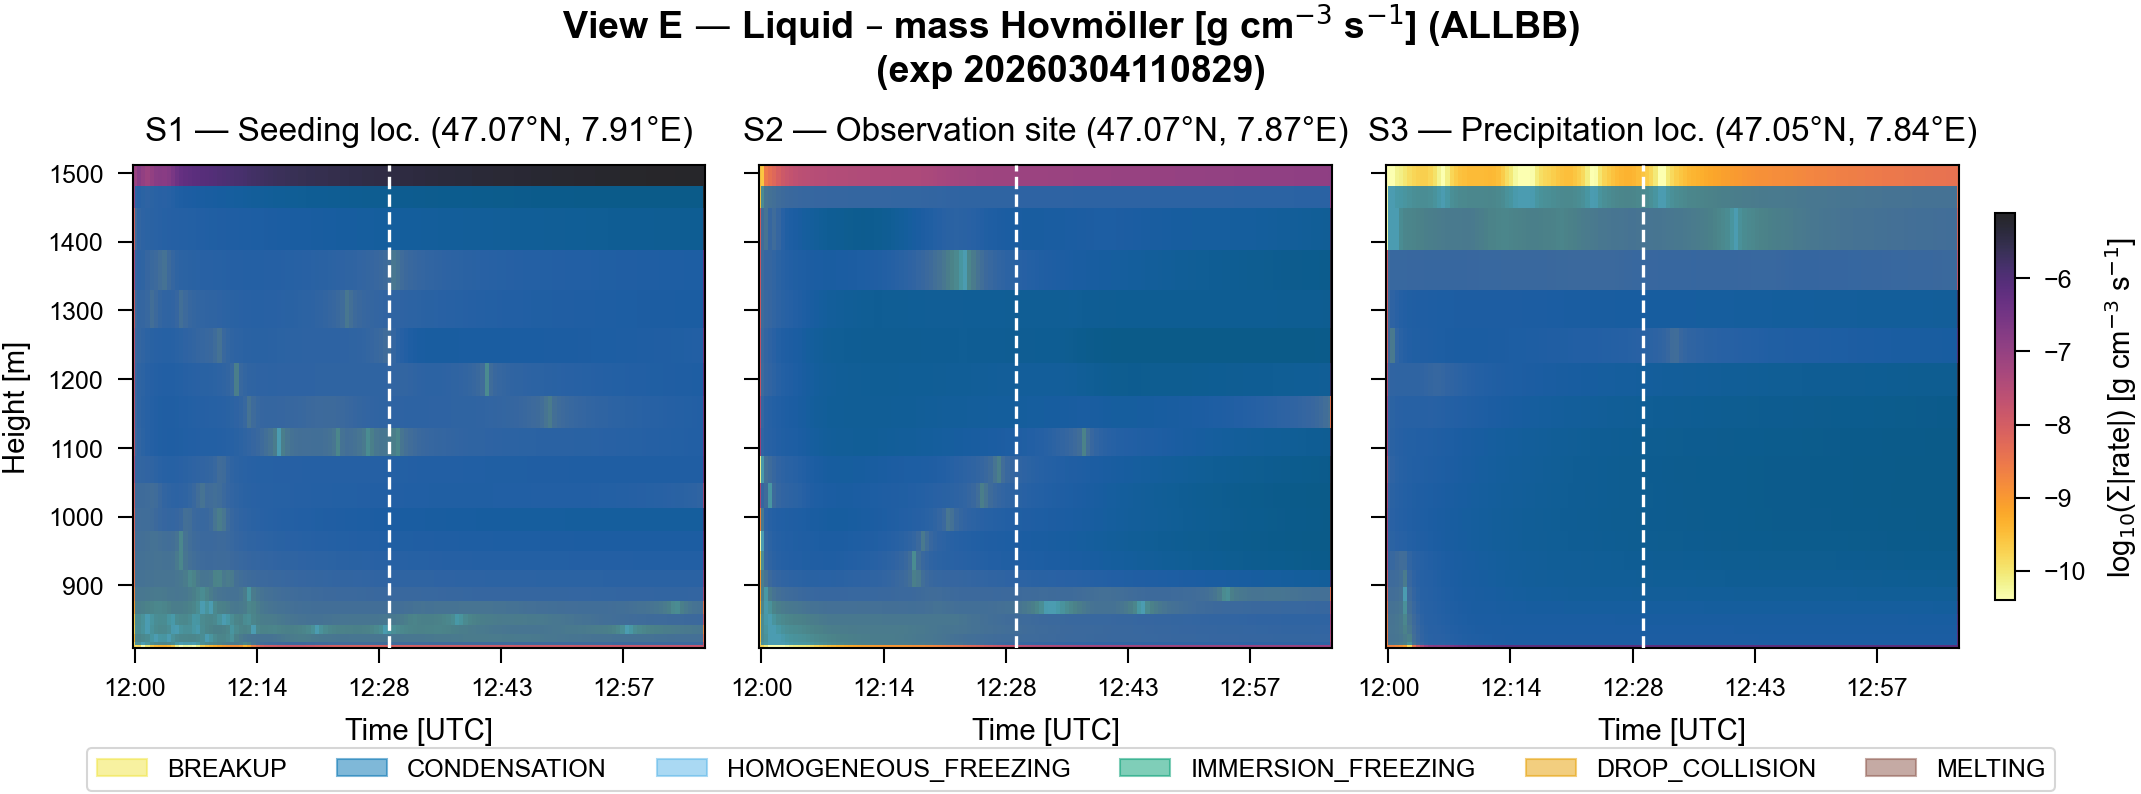

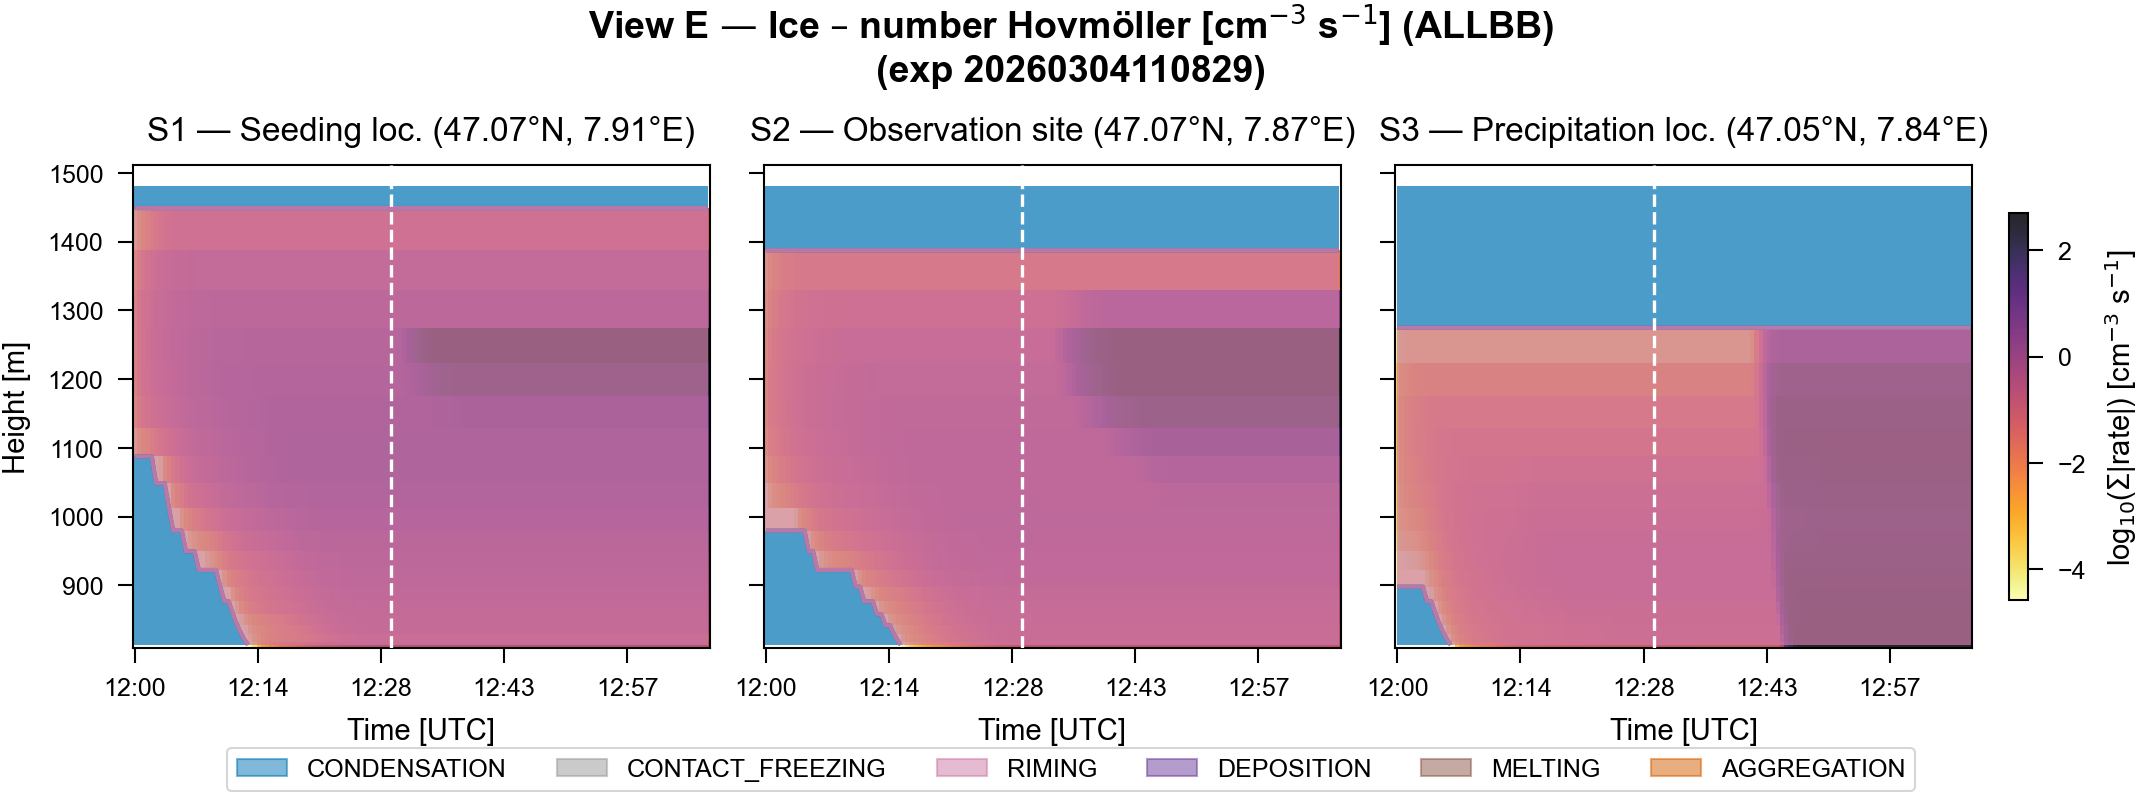

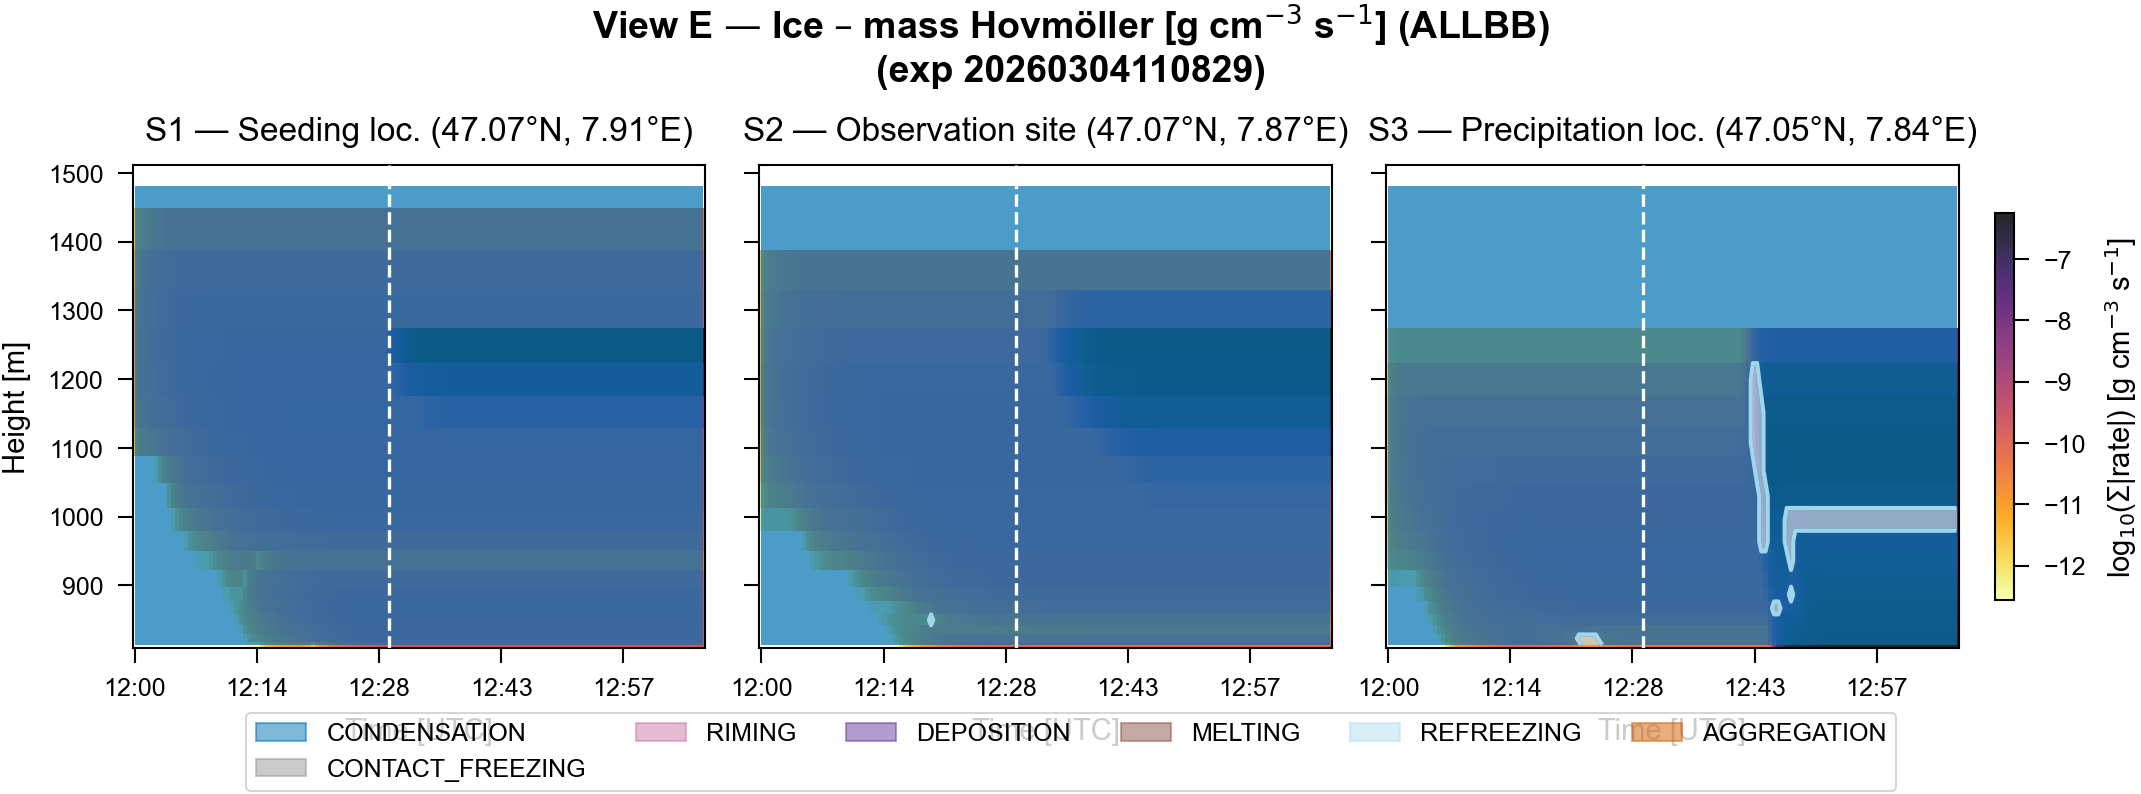

In [ ]:
def plot_hovmoller_budget(rates_dict, unit_label, spectrum_label, range_key=None):
    
    """View E — Hovmöller total-rate heatmap + dominant-process overlay."""
    from matplotlib.patches import Patch

    procs = list(rates_dict.keys())
    colors = [proc_color(p) for p in procs]

    fig, axes = plt.subplots(1, n_stations, figsize=(FULL_COL_IN, 65 * MM),
                             constrained_layout=True, sharey=True)
    if n_stations == 1:
        axes = [axes]

    im = None
    for si, ax in enumerate(axes):
        # region agent log
        if "_dbg_log" in globals():
            _dbg_log("HHOV", "Hovmoller render", {"station": int(si), "range_key": str(range_key or ACTIVE_RANGE_KEY), "n_proc": int(len(procs))})
        # endregion
        # Coarsen time, compute per-process absolute rates
        series = {p: rates_dict[p].isel(station=si)
                     .resample(time=TIME_COARSEN).mean().compute()
                  for p in procs}
        time_vals = series[procs[0]].time.values
        height_vals = series[procs[0]].height_level.values

        # Ensure height is monotonically increasing for contourf
        h_order = np.argsort(height_vals)
        height_sorted = height_vals[h_order]

        t_num = mdates.date2num(time_vals)

        abs_rates = np.array([np.abs(series[p].values[:, h_order])
                              for p in procs])          # (n_proc, time, height)
        total_abs = abs_rates.sum(axis=0)                 # (time, height)
        dominant = np.argmax(abs_rates, axis=0)           # (time, height)

        log_total = np.log10(np.where(total_abs > RATE_FLOOR,
                                      total_abs, np.nan))

        im = ax.pcolormesh(t_num, height_sorted, log_total.T,
                           cmap="inferno_r", shading="nearest", alpha=0.85, vmin=np.nanpercentile(log_total, 0.5))

        # Dominant-process semi-transparent overlay + boundary lines
        for ip, c in enumerate(colors):
            mask = (dominant == ip).astype(float)
            if mask.max() < 0.5:
                continue
            ax.contourf(t_num, height_sorted, mask.T,
                        levels=[0.5, 1.5], colors=[c], alpha=0.7)
            ax.contour(t_num, height_sorted, mask.T, alpha=0.9,
                       levels=[0.5], colors=[c], linewidths=1.)

        ax.axvline(mdates.date2num(SEED_START), color="w", lw=0.8,
                   ls="--", zorder=5)
        ax.set_title(stn_label(si))
        ax.set_xlabel("Time [UTC]")
        if si == 0:
            ax.set_ylabel("Height [m]")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    if im is not None:
        fig.colorbar(im, ax=list(axes),
                     label=f"log$_{{10}}$(Σ|rate|) [{unit_label}]",
                     shrink=0.8, pad=0.02)

    handles = [Patch(facecolor=c, alpha=0.5, edgecolor=c, label=p)
               for p, c in zip(procs, colors)]
    fig.legend(handles=handles, loc="lower center",
               ncol=min(6, len(procs)),
               bbox_to_anchor=(0.5, -0.06))

    fig.suptitle(f"View E — {spectrum_label} Hovmöller [{unit_label}] ({range_key or ACTIVE_RANGE_KEY})\n"
                 f"(exp {exp_label})",
                 fontweight="semibold")
    plt.show()
    return fig, ax

if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS:
        R = rates_by_exp[eid]
        exp_label = R["exp_label"]
        for range_key in PLOT_RANGE_KEYS:
            fig, ax = plot_hovmoller_budget(R[f"rates_N_liq_{range_key}"], R["unit_N"], "Liquid – number", range_key=range_key)
            fig.savefig(f'hovmoller_budget_rates_N_liq_{range_key}.png', dpi=300)
            plot_hovmoller_budget(R[f"rates_Q_liq_{range_key}"], R["unit_Q"], "Liquid – mass", range_key=range_key)
            plot_hovmoller_budget(R[f"rates_N_ice_{range_key}"], R["unit_N"], "Ice – number", range_key=range_key)
            plot_hovmoller_budget(R[f"rates_Q_ice_{range_key}"], R["unit_Q"], "Ice – mass", range_key=range_key)



***View E — Hovmöller total-rate heatmap with dominant-process overlay.** Time–height cross-sections of the total absolute microphysical rate (log$_{10}$-scaled, inferno colour map) at each meteogram station (one panel per station). Semi-transparent coloured contours indicate which process contributes the largest absolute rate in each time–height cell; boundary lines mark the transitions between dominant regimes. Time is coarsened to 1 min to suppress sub-second noise. A dashed white line marks seeding onset (12:30 UTC). Six figures are produced — one for each combination of spectrum (liquid cloud-droplet, ice crystal, precipitation) and tendency kind (number, mass).*

---
## Summary table — time-integrated budget

For quick reference: total positive and negative contribution of each
process, integrated over time and height.

In [20]:
# Available stat names for budget_summary(..., stat_names=...)
BUDGET_STAT_NAMES = ["Mean", "%pos"] #"Mean(+)", "Mean(-)", 

def budget_summary(rates_dict, label, station_ids=None, stat_names=None):
    """Print tables (Mean, Mean(+), Mean(-), %pos) with stations as columns.
    stat_names: which tables to print; default None = all (BUDGET_STAT_NAMES)."""
    procs = list(rates_dict.keys())
    n_st = rates_dict[procs[0]].sizes["station"]
    if station_ids is None:
        station_ids = list(range(n_st))
    st_short = [STATION_LABELS.get(si, "Stn" + str(si)).split(" — ")[0].strip() for si in station_ids]



    rows = []
    for p in procs:
        row = {"process": p}
        for si in station_ids:
            v = rates_dict[p].isel(station=si).values.ravel()
            v = v[np.isfinite(v)]
            row[si] = {
                "mean": np.mean(v) if v.size else np.nan,
                "mean_pos": np.mean(v[v > 0]) if np.any(v > 0) else 0.0,
                "mean_neg": np.mean(v[v < 0]) if np.any(v < 0) else 0.0,
                "frac_pos": np.mean(v > 0) if v.size else 0.0,
            }
        rows.append(row)

    def max_abs_mean(row):
        return max(abs(row[si]["mean"]) for si in station_ids)
    sorted_rows = sorted(rows, key=max_abs_mean, reverse=True)

    w = 12
    sep = "  "
    n_cols = 1 + len(station_ids)

    stats_list = [
        ("Mean", "mean", "{:12.3e}"),
        ("Mean(+)", "mean_pos", "{:12.3e}"),
        ("Mean(-)", "mean_neg", "{:12.3e}"),
        ("%pos", "frac_pos", "{:12.1%}"),
    ]
    to_show = stat_names if stat_names is not None else BUDGET_STAT_NAMES
    for stat_name, key, fmt in stats_list:
        if stat_name not in to_show:
            continue
        print("\n  --- " + label + "  |  " + stat_name + " ---")
        print("  " + "{:30s}".format("Process") + sep + sep.join(["{:>12s}".format(s) for s in st_short]))
        print("  " + "-" * 30 + sep + sep.join(["-" * w] * len(station_ids)))
        for r in sorted_rows:
            line = "  {:30s}".format(r["process"])
            for si in station_ids:
                line += sep + fmt.format(r[si][key])
            print(line)


if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS:
        R = rates_by_exp[eid]
        print(f"\n=== Experiment {eid}: {R['exp_label']} ===")
        budget_summary(R["rates_N_liq"], "Liquid – number", station_ids=PLOT_STN_IDS)
        budget_summary(R["rates_Q_liq"], "Liquid – mass", station_ids=PLOT_STN_IDS)
        budget_summary(R["rates_N_ice"], "Ice – number", station_ids=PLOT_STN_IDS)
        budget_summary(R["rates_Q_ice"], "Ice – mass", station_ids=PLOT_STN_IDS)
        budget_summary(R["rates_N_pcp"], "Precip – number (bins 50–65)", station_ids=PLOT_STN_IDS)
        budget_summary(R["rates_Q_pcp"], "Precip – mass (bins 50–65)", station_ids=PLOT_STN_IDS)



=== Experiment 1: 20260304110638 ===

  --- Liquid – number  |  Mean ---
  Process                                   S1            S2            S3
  ------------------------------  ------------  ------------  ------------
  CONDENSATION                       2.994e+02    -5.993e+02     2.021e+02
  DROP_COLLISION                    -2.581e+00    -3.120e+00    -1.619e+00
  IMMERSION_FREEZING                 5.117e-05     4.112e-05     2.399e-05
  BREAKUP                            0.000e+00     0.000e+00     0.000e+00
  HOMOGENEOUS_FREEZING               0.000e+00     0.000e+00     0.000e+00
  MELTING                            0.000e+00     0.000e+00     0.000e+00

  --- Liquid – number  |  %pos ---
  Process                                   S1            S2            S3
  ------------------------------  ------------  ------------  ------------
  CONDENSATION                           39.9%         20.8%         43.9%
  DROP_COLLISION                          8.5%         11.8%     

***Table — Time-integrated microphysical budget.** For each spectrum (liquid, ice) and tendency kind (number, mass), lists the time- and height-averaged net rate, mean positive (source) rate, mean negative (sink) rate, and fraction of grid cells with a positive tendency for every resolved microphysical process. Processes are sorted by decreasing absolute net rate. All rates are volumetric, converted from raw specific tendencies by multiplication with air density (see Unit conversion in the introduction).*